### “This project analyzes Citi Bike usage patterns to identify high-demand stations and temporal trends in bike usage.”

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\kanap\Downloads\citi_bike_trip_data.csv")

## 🔍 Data Understanding

Before diving into analysis, we explore the dataset to understand:
- Data types
- Missing values
- Feature distributions

This step ensures data quality and guides further analysis.

In [3]:
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,326,2013-10-01 00:01:08,2013-10-01 00:06:34,239,Willoughby St & Fleet St,40.691966,-73.981302,366,Clinton Ave & Myrtle Ave,40.693261,-73.968896,16052,Subscriber,1982,1
1,729,2013-10-01 00:01:21,2013-10-01 00:13:30,322,Clinton St & Tillary St,40.696192,-73.991218,398,Atlantic Ave & Furman St,40.691652,-73.999979,19412,Customer,\N,0
2,520,2013-10-01 00:01:24,2013-10-01 00:10:04,174,E 25 St & 1 Ave,40.738177,-73.977387,403,E 2 St & 2 Ave,40.725029,-73.990697,19645,Subscriber,1984,1
3,281,2013-10-01 00:01:25,2013-10-01 00:06:06,430,York St & Jay St,40.701485,-73.986569,323,Lawrence St & Willoughby St,40.692362,-73.986317,16992,Subscriber,1985,1
4,196,2013-10-01 00:01:27,2013-10-01 00:04:43,403,E 2 St & 2 Ave,40.725029,-73.990697,401,Allen St & Rivington St,40.720196,-73.989978,15690,Subscriber,1986,1


In [12]:
df.shape

(40575, 15)

### 📄 Inspecting the Dataset

We begin by examining the structure of the dataset, including:
- Number of rows and columns
- Data types
- Sample records

This helps us understand how to preprocess the data.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40575 entries, 0 to 40574
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tripduration             40575 non-null  int64  
 1   starttime                40575 non-null  object 
 2   stoptime                 40575 non-null  object 
 3   start station id         40575 non-null  int64  
 4   start station name       40575 non-null  object 
 5   start station latitude   40575 non-null  float64
 6   start station longitude  40575 non-null  float64
 7   end station id           40575 non-null  int64  
 8   end station name         40575 non-null  object 
 9   end station latitude     40575 non-null  float64
 10  end station longitude    40575 non-null  float64
 11  bikeid                   40575 non-null  int64  
 12  usertype                 40575 non-null  object 
 13  birth year               40575 non-null  object 
 14  gender                

### 📊 Statistical Summary of Dataset

We begin by analyzing key statistical metrics of the dataset using `.describe()`.

This provides insights into:
- Data distribution
- Central tendency (mean, median)
- Variability (standard deviation)
- Potential outliers

Understanding these metrics helps identify anomalies and guides further data cleaning and analysis.

In [13]:
df.describe()

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,gender
count,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000
mean,822.374640,449.396155,40.735229,-73.991093,450.073370,40.734885,-73.991212,17634.191547,1.137671
std,984.000376,362.462577,0.019599,0.012346,369.780126,0.019600,0.012483,1703.451047,0.527477
min,60.000000,72.000000,40.680342,-74.017134,72.000000,40.680342,-74.017134,14531.000000,0.000000
25%,408.000000,306.000000,40.721816,-74.000264,305.000000,40.721816,-74.001497,16146.000000,1.000000
50%,638.000000,405.000000,40.737050,-73.990765,404.000000,40.736529,-73.990931,17651.000000,1.000000
75%,1028.000000,487.000000,40.750450,-73.982050,487.000000,40.750224,-73.982050,19093.000000,1.000000
max,56629.000000,3002.000000,40.770513,-73.950048,3002.000000,40.770513,-73.950048,20664.000000,2.000000


### 📈 Key Insights

- Most trips are short, with an average duration of around 13–14 minutes.
- There are some very large values in trip duration, indicating possible outliers.
- Data is concentrated within a specific geographic area based on latitude and longitude.
- Gender is stored as numeric values, suggesting categorical encoding.

---

### 💼 Business Insight

- The service is mainly used for short-distance travel, likely for daily commuting.

---

### 🔧 Note

- Some extreme values and encoded fields are observed and can be further refined in future improvements.

<Axes: xlabel='tripduration', ylabel='Count'>

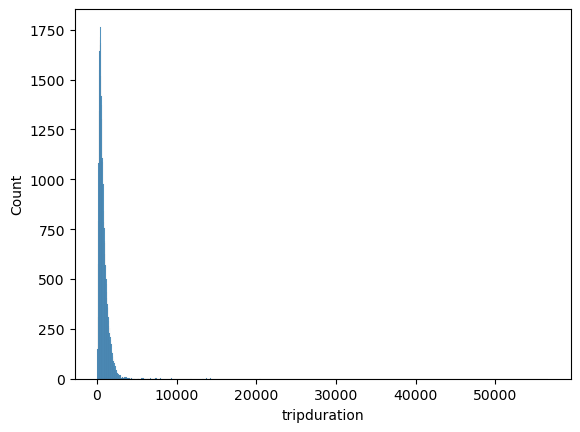

In [14]:
sns.histplot(df['tripduration'])

### 📈 Key Insights

- Most trip durations are very low and concentrated near the beginning.
- The distribution is highly skewed to the right.
- A few extremely large values stretch the graph significantly.

---

### 💼 Business Insight

- The majority of users take short trips, indicating the service is mainly used for quick travel or commuting.

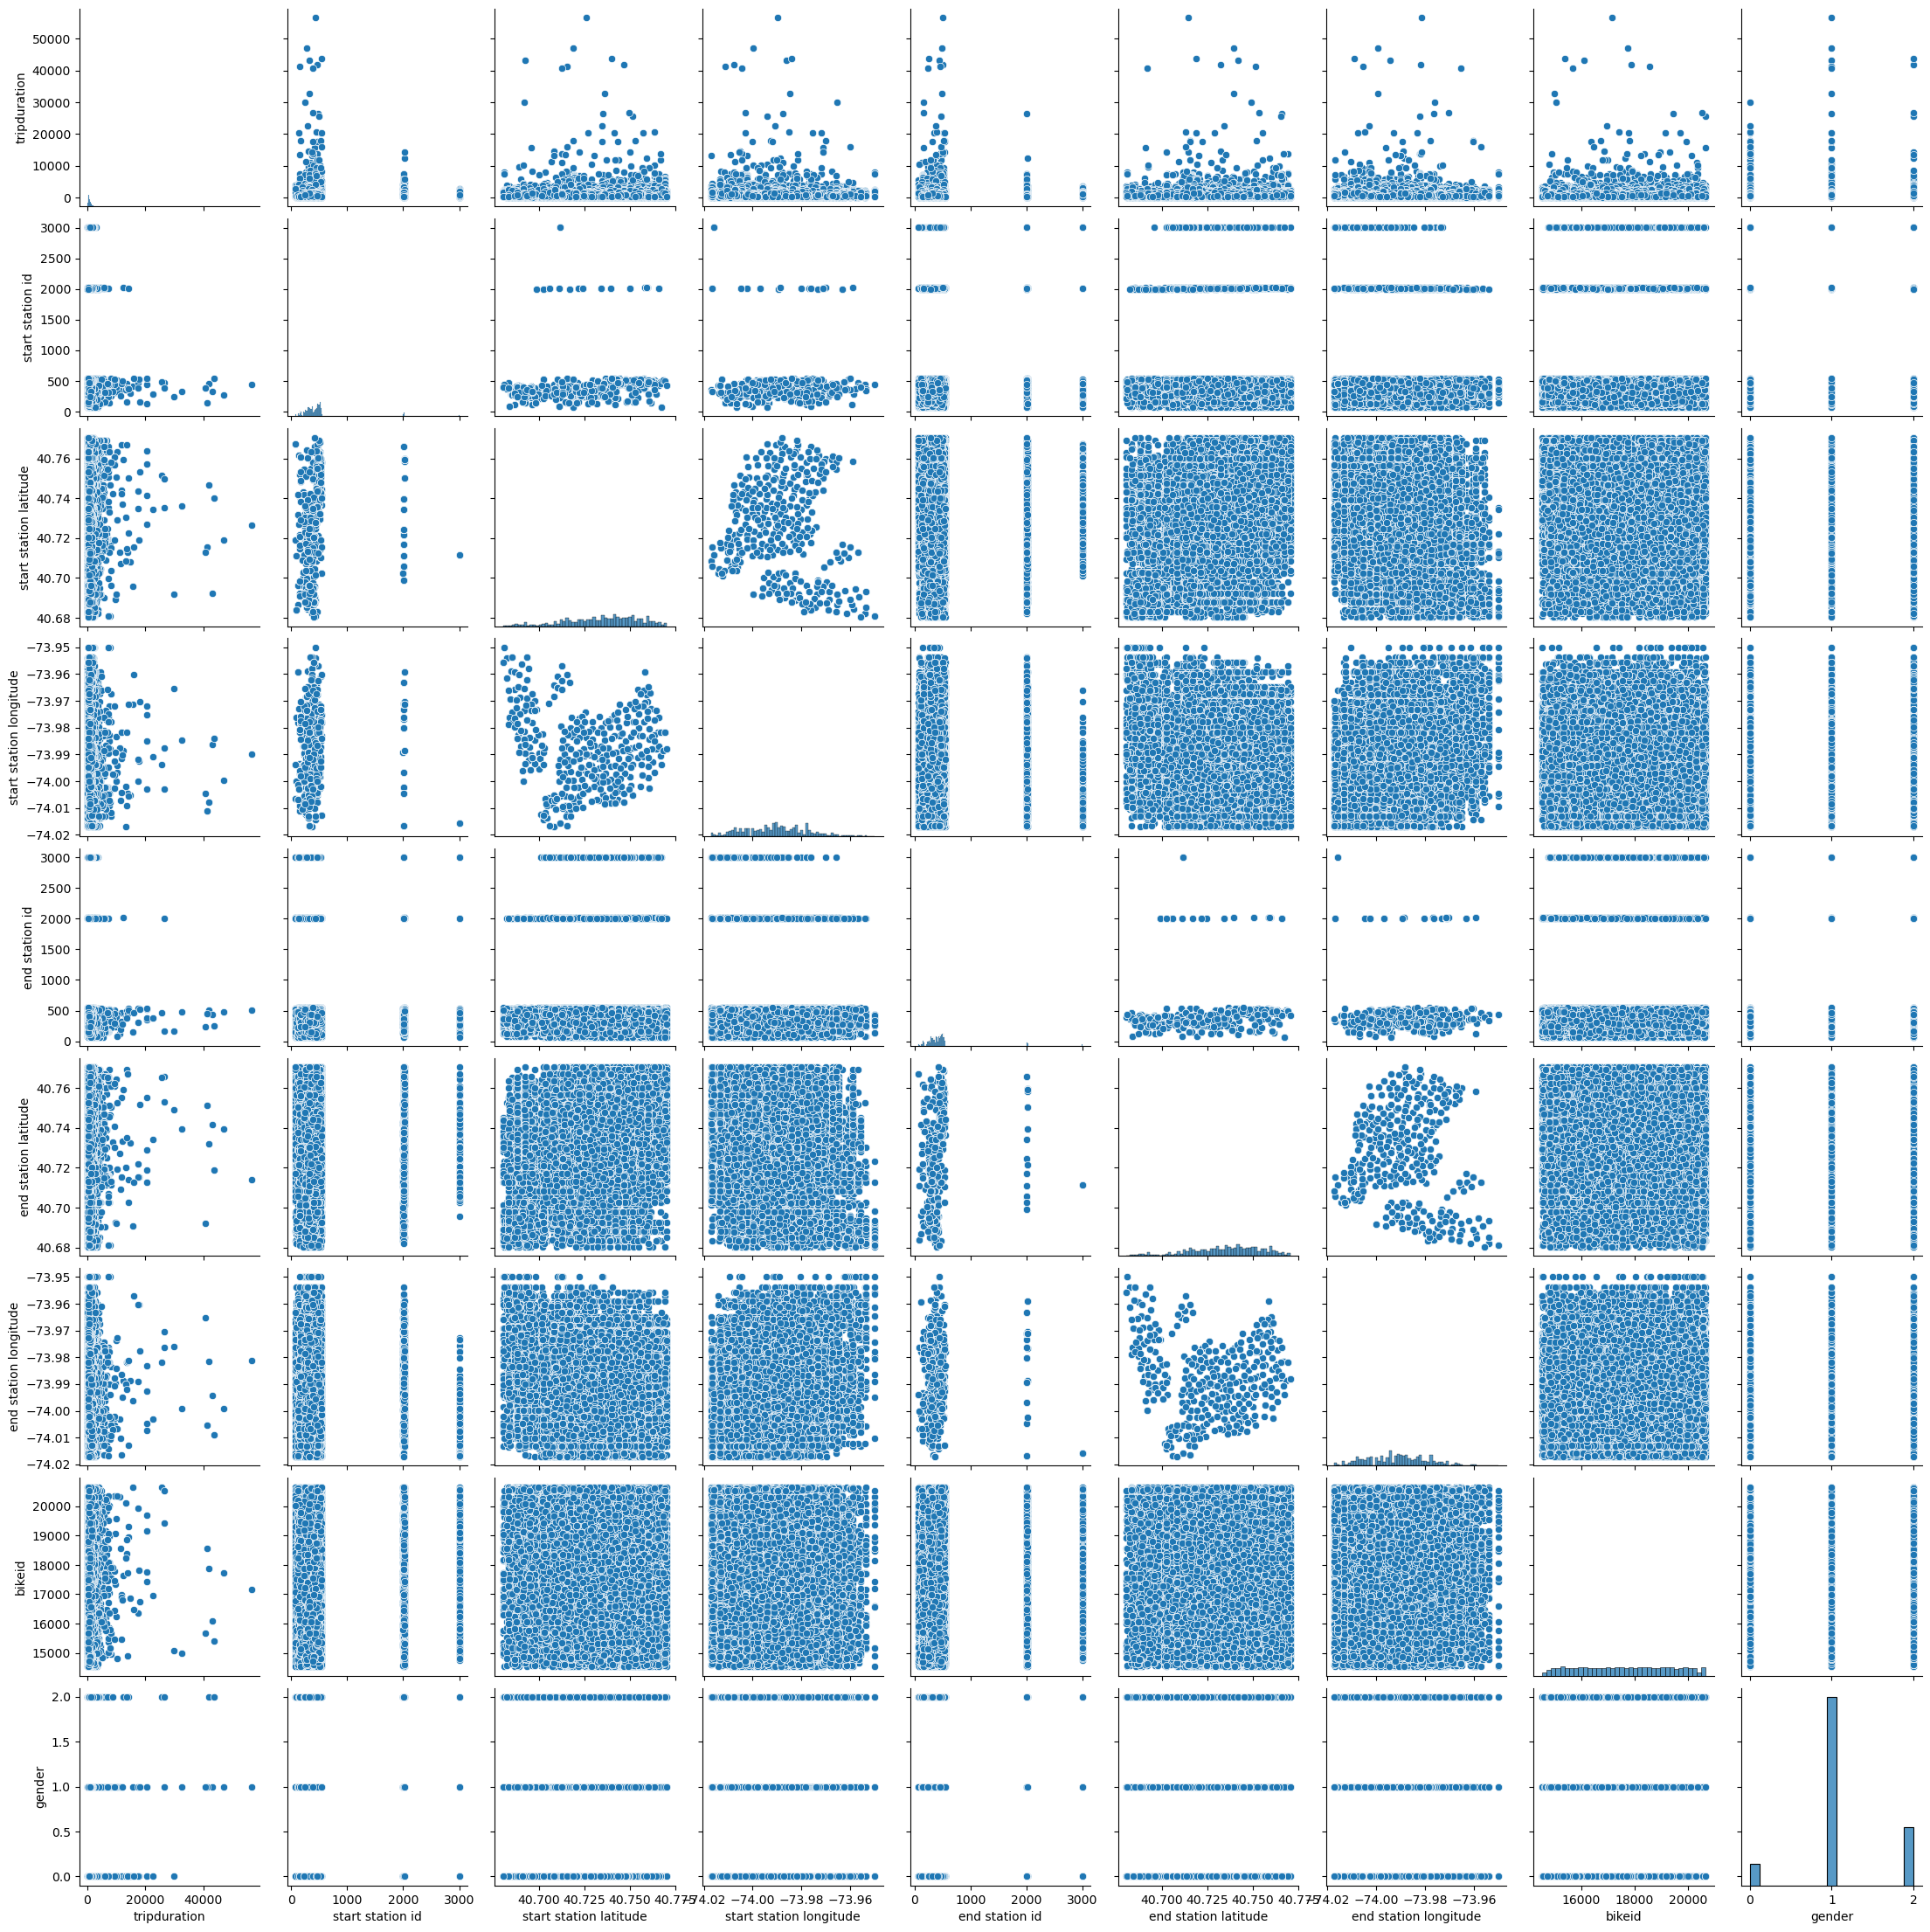

In [15]:
sns.pairplot(df)

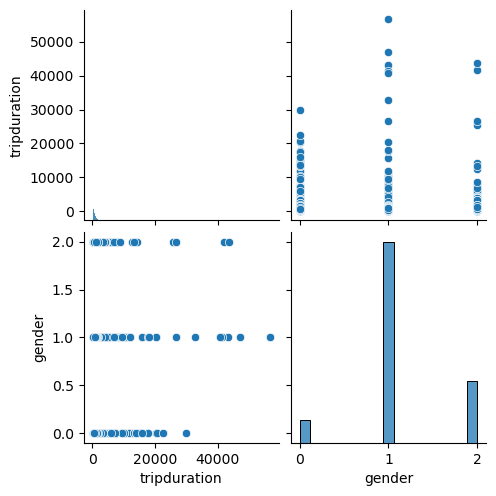

In [16]:
sns.pairplot(df[['tripduration','gender']])

### 📈 Key Insights

- Male users (1) have the highest number of trips.
- Female users (2) have fewer trips compared to males.
- Unknown category (0) has the lowest participation.

---

### 💼 Business Insight

- The service is more frequently used by male users, indicating a potential gap in adoption among other groups.

In [18]:
num_subscriber = df['usertype'].loc[df['usertype']=='Subscriber'].count()
total =len(df)
print(round(num_subscriber/total*100,2), '% of total riders on October 1st,2013 are annual subscribers')

92.03 % of total riders on October 1st,2013 are annual subscribers


### 💼 Business Insight

- The service is heavily driven by loyal, subscription-based users, indicating strong customer retention.

### How does the trip length vary based on the trip start time?

In [19]:
df['Hour']=df.starttime.apply(lambda x:x[11:13]).astype('str')

<Axes: xlabel='Hour', ylabel='tripduration'>

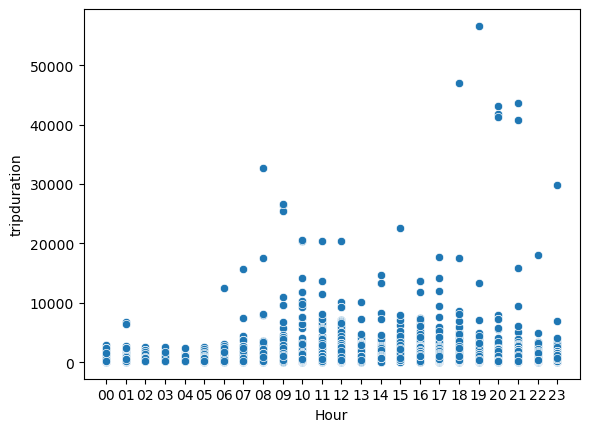

In [20]:
sns.scatterplot(x ='Hour' ,y='tripduration', data =df) #correlation

<Axes: xlabel='Hour', ylabel='tripduration'>

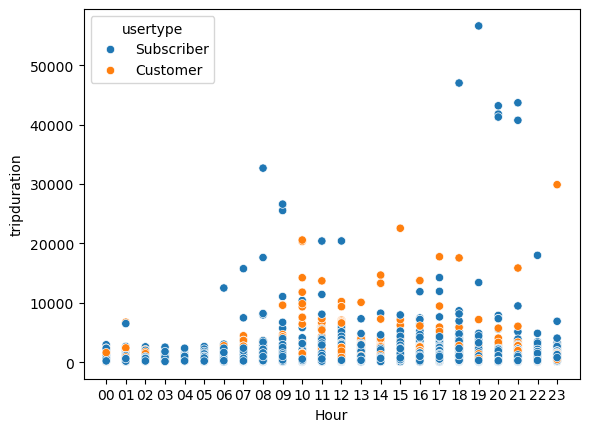

In [21]:
sns.scatterplot(x ='Hour' ,y='tripduration', data =df, hue='usertype') #correlation

### Which stations are popular for Trip start?

In [22]:
df2 =df.groupby(['start station id']).size().reset_index(name='counts')

In [23]:
df2

,start station id,counts
0,72,112
1,79,91
2,82,39
3,83,52
4,116,213
...,...,...
323,2017,127
324,2021,228
325,2022,105
326,2023,74


In [24]:
temp=df.drop_duplicates('start station id')
#left join
df2=pd.merge(df2,temp[['start station id','start station name',
                       'start station latitude','start station longitude']], 
             how='left', on=['start station id'])

In [25]:
!pip install folium

In [26]:
import folium

In [27]:
#initialise a map
m=folium.Map(location=[40.691966,-73.981302],titles='OpenStreetMap', zoom_start=12)
m

In [29]:
for i in range(0,len(df2)):
    folium.Circle(
        location=[df2.iloc[i]['start station latitude'],df.iloc[i]['start station longitude']],
        popup=df2.iloc[i]['start station name'],
        radius = float(df2.iloc[i]['counts'])/2,
        color ='red',
        fill=True,fill_color='red').add_to(m)
m

In [31]:
hourly_counts = df['hour'].value_counts().sort_index()

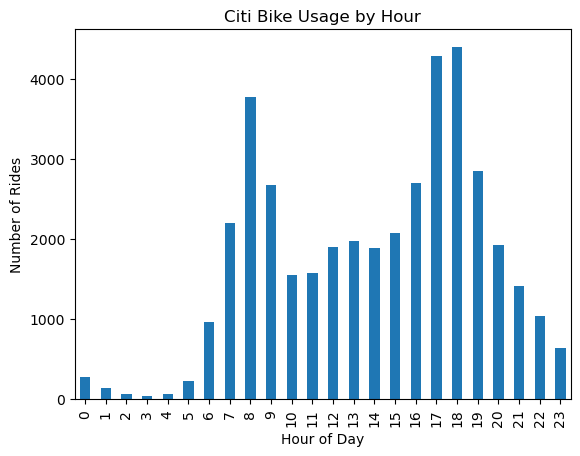

In [32]:
import matplotlib.pyplot as plt

hourly_counts.plot(kind='bar')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.title("Citi Bike Usage by Hour")
plt.show()

✅ What I  see is 
X-axis → hours (0–23)
Y-axis → number of rides
Peaks = busiest times

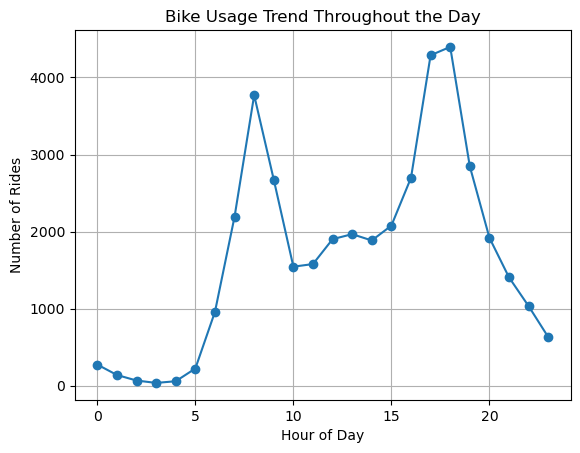

In [33]:
plt.figure()
hourly_counts.plot(kind='line', marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.title("Bike Usage Trend Throughout the Day")

plt.grid()
plt.show()

* Peak usage at 8–9 AM → morning commute
* Another peak at 5–6 PM → evening commute
* Low usage late night

## Insights:

* Usage typically peaks during morning (around 7–9 AM) and evening (around 5–7 PM), indicating commuting patterns.
* Midday activity is moderate, suggesting leisure or short trips.
* Late night and early morning hours show very low usage.